## Load Data from Google Drive

## Unzipping the provided archive

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (2).zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

'/content/archive (2).zip' unzipped to '/content/extracted_data'
Contents of the extracted directory:
/content/extracted_data/photo_tags.csv
/content/extracted_data/users.csv
/content/extracted_data/comments.csv
/content/extracted_data/likes.csv
/content/extracted_data/photos.csv
/content/extracted_data/follows.csv
/content/extracted_data/tags.csv


In [ ]:
import pandas as pd

users_df_path = os.path.join(extract_dir, 'users.csv')
users_df = pd.read_csv(users_df_path)

print(f"Loaded '{users_df_path}' into a pandas DataFrame.")
display(users_df.head())

Loaded '/content/extracted_data/users.csv' into a pandas DataFrame.


,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no


In [ ]:
print("Missing values in users_df:")
display(users_df.isnull().sum())

Missing values in users_df:


,0
id,0
name,0
created time,0
private/public,0
post count,0
Verified status,0


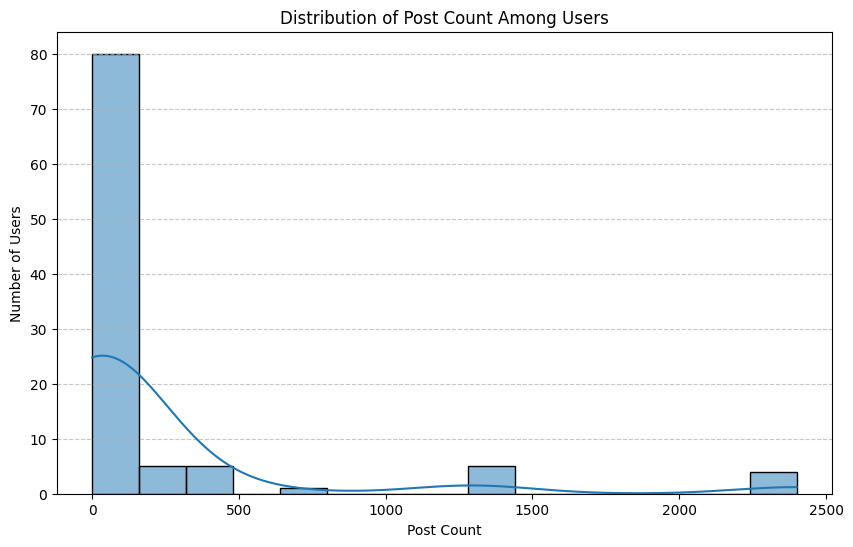

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(users_df['post count'], bins=15, kde=True)
plt.title('Distribution of Post Count Among Users')
plt.xlabel('Post Count')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

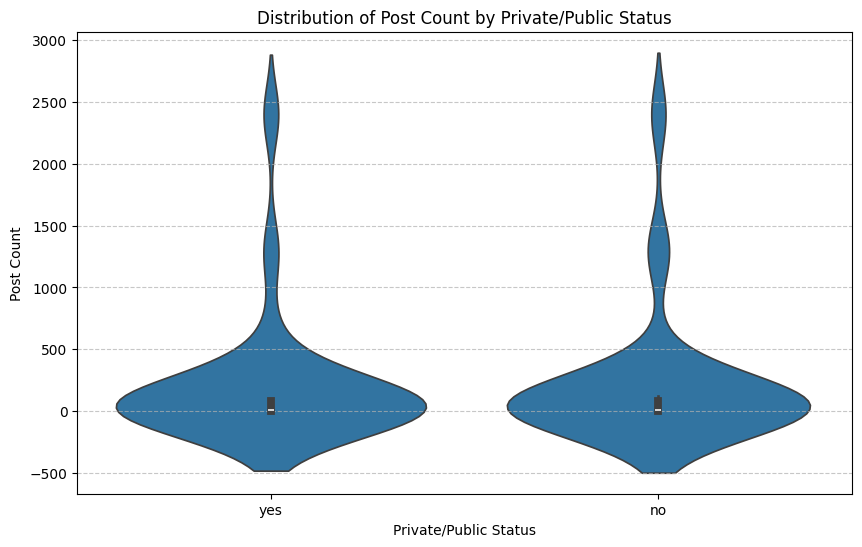

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='private/public', y='post count', data=users_df)
plt.title('Distribution of Post Count by Private/Public Status')
plt.xlabel('Private/Public Status')
plt.ylabel('Post Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Unique values in 'private/public' column:")
display(users_df['private/public'].unique())

Unique values in 'private/public' column:


array(['yes', 'no'], dtype=object)

### Descriptive Statistics

In [ ]:
print("Descriptive statistics for users_df:")
display(users_df.describe())

Descriptive statistics for users_df:


,id,post count
count,100.000000,100.000000
mean,50.500000,215.370000
std,29.011492,534.756995
min,1.000000,0.000000
25%,25.750000,2.000000
50%,50.500000,12.000000
75%,75.250000,78.000000
max,100.000000,2400.000000


### Data Type Conversion for 'created time'

In [ ]:
users_df['created time'] = pd.to_datetime(users_df['created time'], format='%d-%m-%Y %H:%M')
print("Data types after converting 'created time':")
display(users_df.info())

Data types after converting 'created time':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               100 non-null    int64         
 1   name             100 non-null    object        
 2   created time     100 non-null    datetime64[ns]
 3   private/public   100 non-null    object        
 4   post count       100 non-null    int64         
 5   Verified status  100 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 4.8+ KB


None

### Distribution of 'Verified status'

In [ ]:
print("Value counts for 'Verified status':")
display(users_df['Verified status'].value_counts())

Value counts for 'Verified status':


,count
Verified status,
no,92
yes,8


/tmp/ipykernel_1363/2815211608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Verified status', data=users_df, palette='viridis')


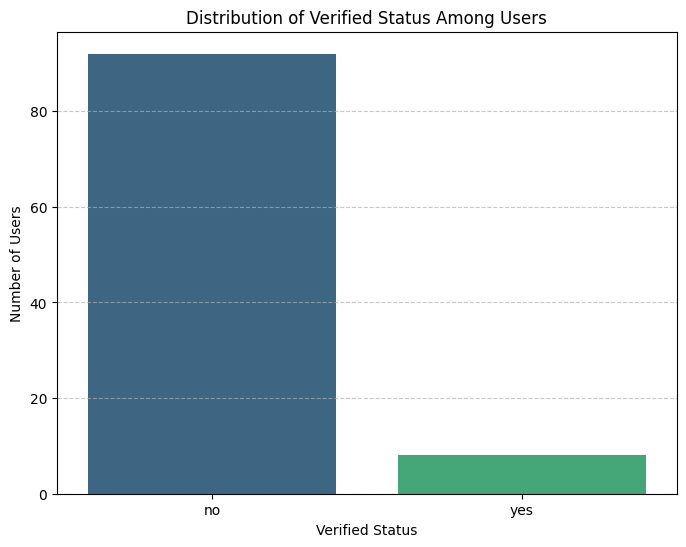

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Verified status', data=users_df, palette='viridis')
plt.title('Distribution of Verified Status Among Users')
plt.xlabel('Verified Status')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()